/home/pyvenvs/scratch-3.12/lib/python3.12/site-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.679%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2018-01-03
End date,2022-12-30
Total months,59
,Backtest
Annual return,2.679%
Cumulative returns,14.107%
Annual volatility,5.76%
Sharpe ratio,0.49
Calmar ratio,0.54
Stability,0.92
Max drawdown,-4.981%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,4.98,2020-03-02,2020-03-23,2020-11-03,177
1,4.88,2022-03-22,2022-05-20,2022-07-27,92
2,4.76,2022-09-12,2022-11-03,NaT,NaN
3,4.75,2021-12-10,2022-01-25,2022-03-22,73
4,2.79,2021-05-26,2021-09-30,2021-10-18,104


/home/pyvenvs/scratch-3.12/lib/python3.12/site-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])
/home/pyvenvs/scratch-3.12/lib/python3.12/site-packages/pyfolio/tears.py:1005: UserWarning: Passed returns do not overlap with anyinteresting times.
  warnings.warn(


Top 10 long positions of all time,max
MSFT,33.05%
GOOG,17.07%


Top 10 short positions of all time,max


Top 10 positions of all time,max
MSFT,33.05%
GOOG,17.07%


/home/pyvenvs/scratch-3.12/lib/python3.12/site-packages/pyfolio/pos.py:100: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  longs = expos.where(expos.applymap(lambda x: x > 0))
/home/pyvenvs/scratch-3.12/lib/python3.12/site-packages/pyfolio/pos.py:101: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  shorts = expos.where(expos.applymap(lambda x: x < 0))
/home/pyvenvs/scratch-3.12/lib/python3.12/site-packages/pyfolio/plotting.py:323: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_holdings_by_month = df_holdings.resample("1M").mean()
/home/pyvenvs/scratch-3.12/lib/python3.12/site-packages/pyfolio/plotting.py:1465: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_turnover_by_month = df_turnover.resample("M").mean()


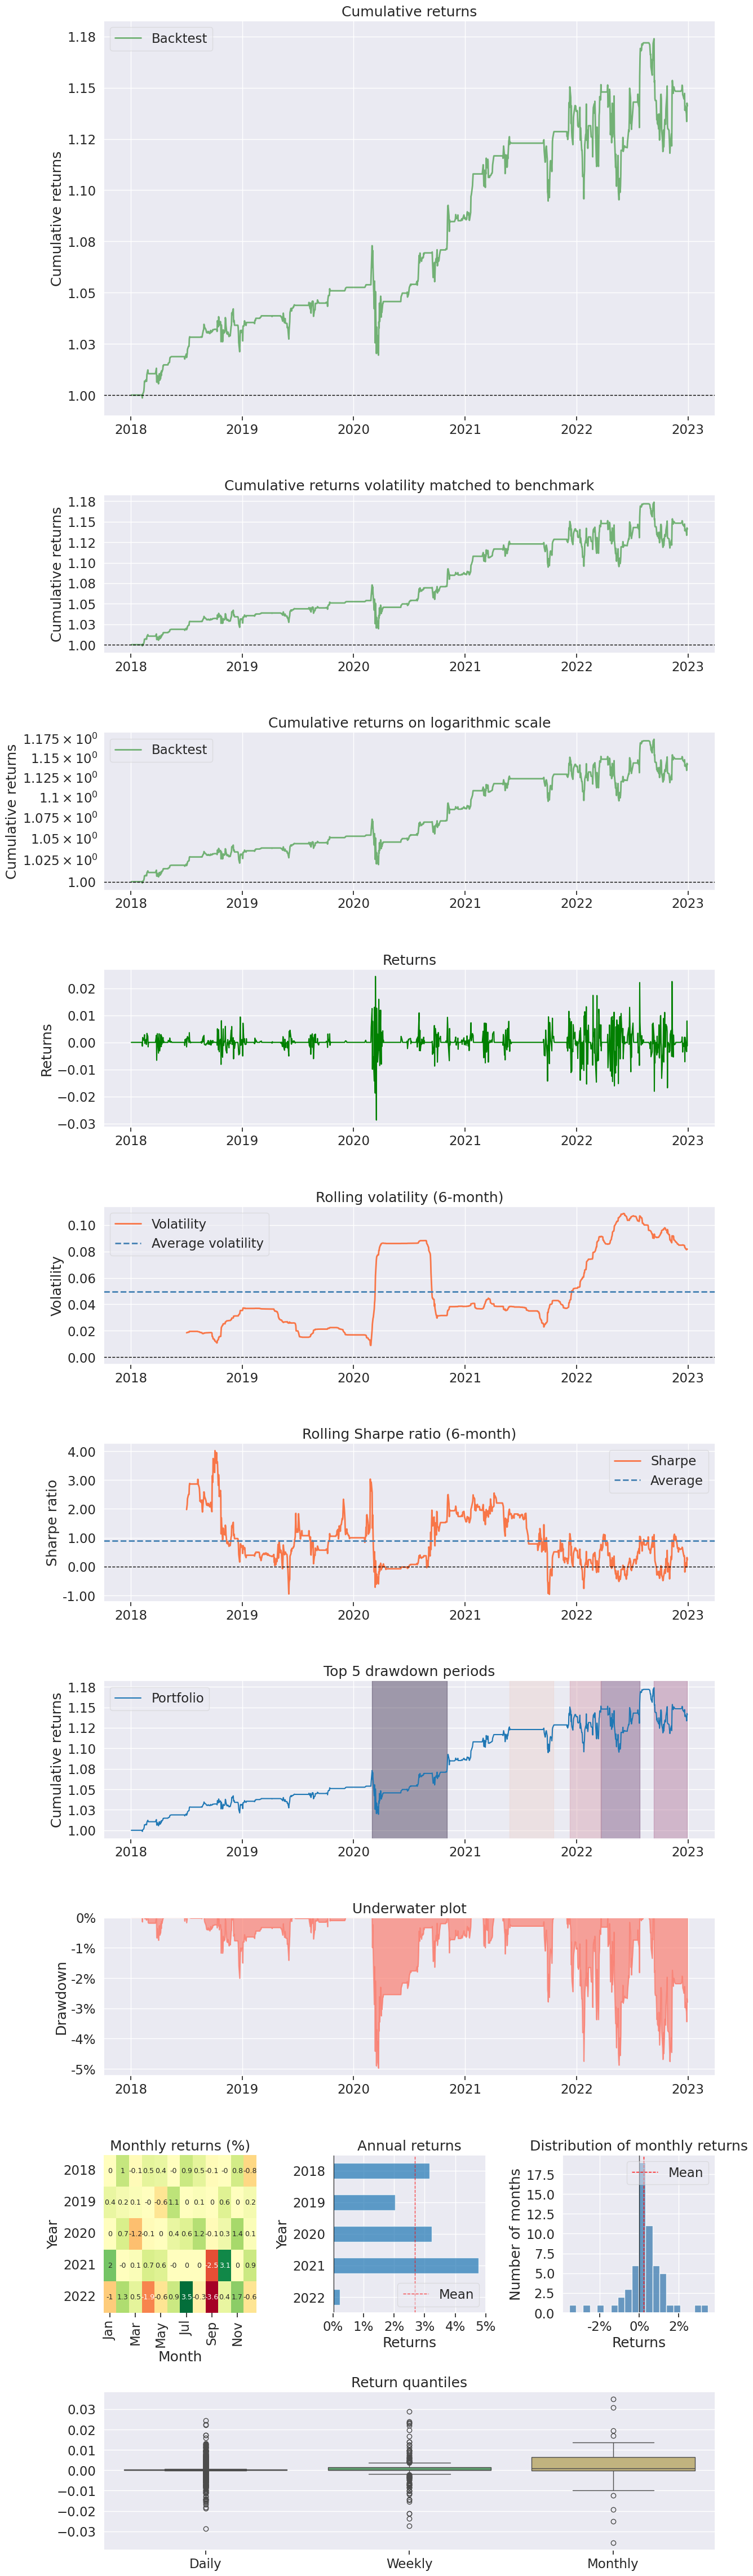

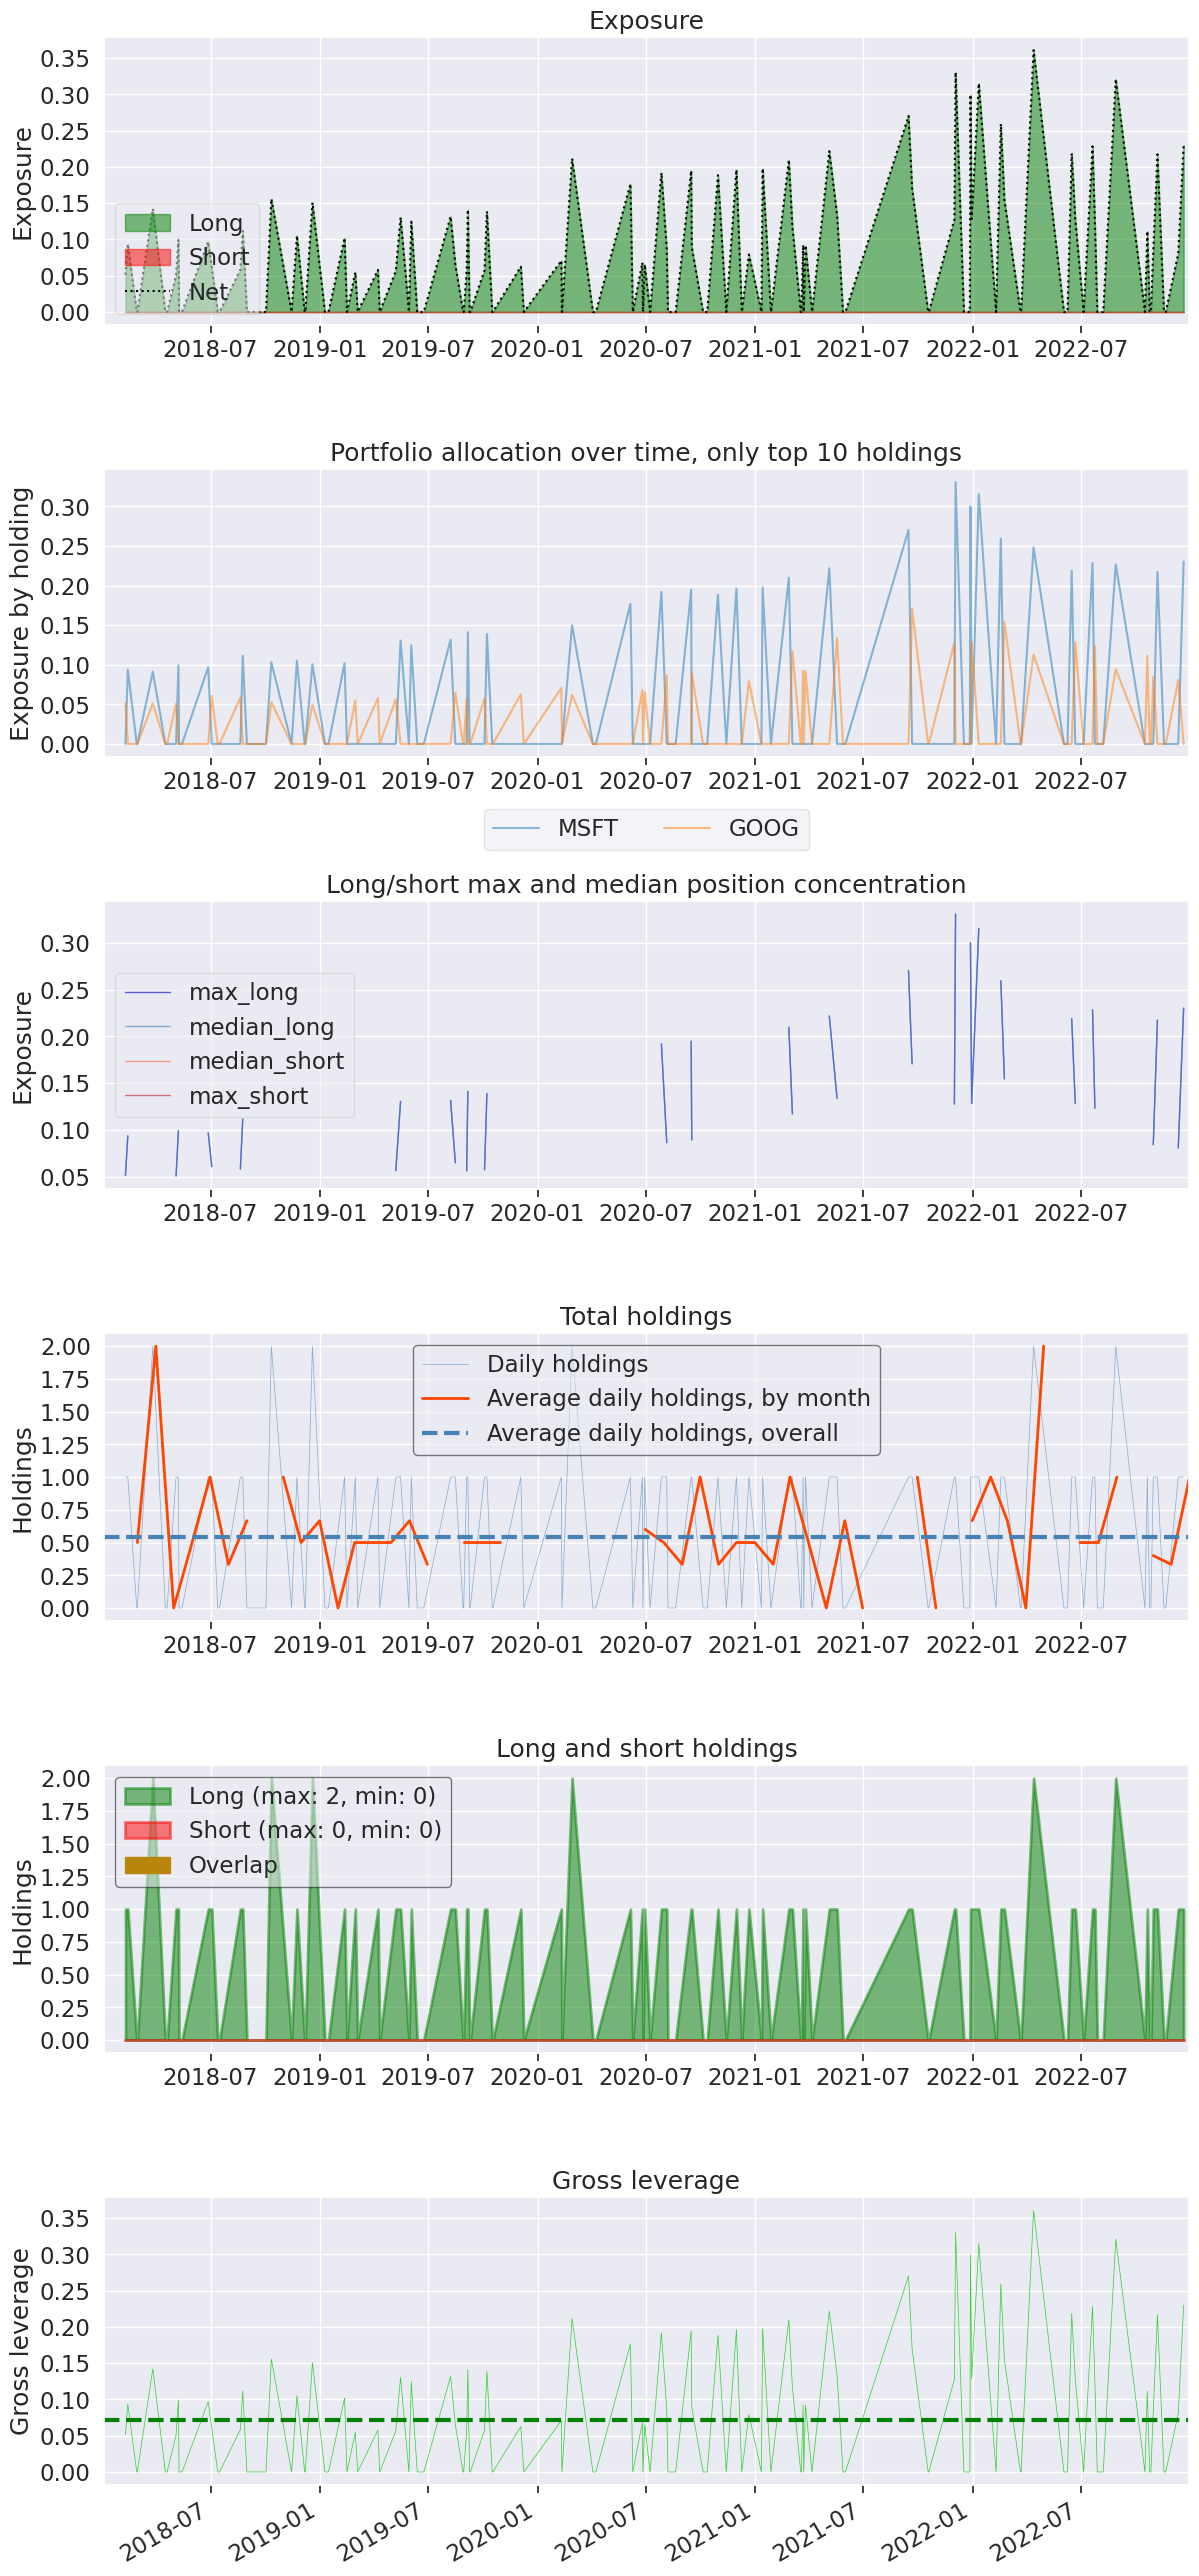

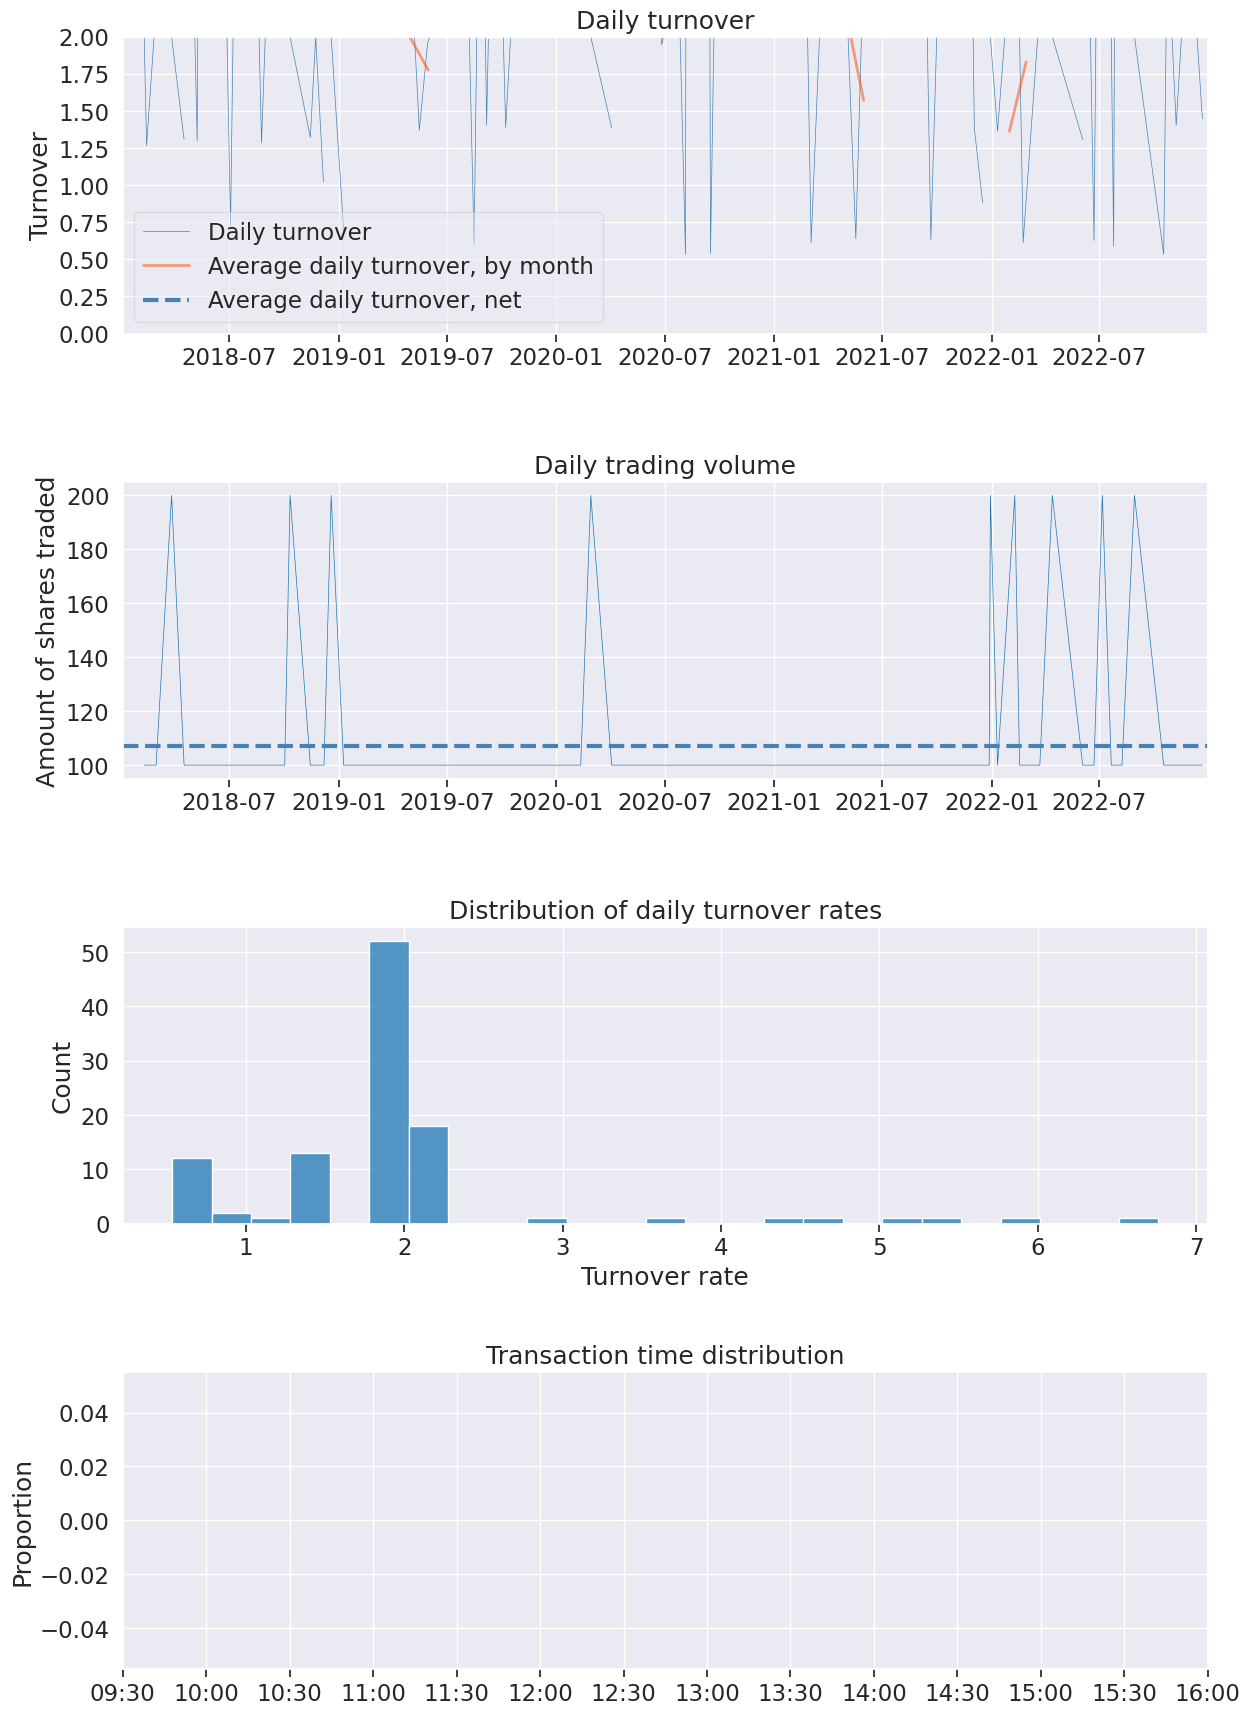

In [ ]:
import pandas as pd
import pyfolio as pf

from yabte.backtest import Book, SimpleOrder, Strategy, StrategyRunner
from yabte.tests._helpers import generate_nasdaq_dataset
from yabte.utilities.pyfolio import extract_rets_pos_txn_from_yabte
from yabte.utilities.strategy_helpers import crossover


class SMAXO(Strategy):
    def init(self):
        # enhance data with simple moving averages

        p = self.params
        days_short = p.get("days_short", 10)
        days_long = p.get("days_long", 20)

        close_sma_short = (
            self.data.loc[:, (slice(None), "Close")]
            .rolling(days_short)
            .mean()
            .rename({"Close": "CloseSMAShort"}, axis=1, level=1)
        )
        close_sma_long = (
            self.data.loc[:, (slice(None), "Close")]
            .rolling(days_long)
            .mean()
            .rename({"Close": "CloseSMALong"}, axis=1, level=1)
        )
        self.data = pd.concat(
            [self.data, close_sma_short, close_sma_long], axis=1
        ).sort_index(axis=1)

    def on_close(self):
        # create some orders

        for symbol in ["GOOG", "MSFT"]:
            df = self.data[symbol]
            ix_2d = df.index[-2:]
            data = df.loc[ix_2d, ("CloseSMAShort", "CloseSMALong")].dropna()
            if len(data) == 2:
                if crossover(data.CloseSMAShort, data.CloseSMALong):
                    self.orders.append(SimpleOrder(asset_name=symbol, size=-100))
                elif crossover(data.CloseSMALong, data.CloseSMAShort):
                    self.orders.append(SimpleOrder(asset_name=symbol, size=100))


# load some data
assets, df_combined = generate_nasdaq_dataset()

# create a book with 100000 cash
book = Book(name="Main", cash="100000")

# run our strategy
sr = StrategyRunner(
    data=df_combined,
    assets=assets,
    strategies=[SMAXO()],
    books=[book],
)
srr = sr.run()

# extract information for pyfolio
# and create a full tear sheet
returns, positions, transactions = extract_rets_pos_txn_from_yabte(srr)
pf.create_full_tear_sheet(returns, positions=positions, transactions=transactions)